1. Import the required Python libraries.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2. Create the Boolean logic datasets (AND, OR, and NOT).

In [ ]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_and = np.array([0, 0, 0, 1], dtype=float)
y_or = np.array([0, 1, 1, 1], dtype=float)

X_not = np.array([
    [0],
    [1]
], dtype=float)

y_not = np.array([1, 0], dtype=float)

3. Visualize the input data distribution.

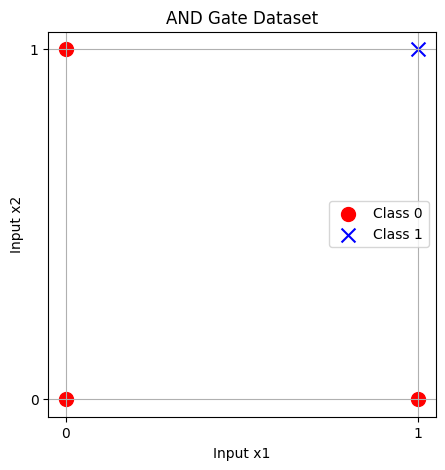

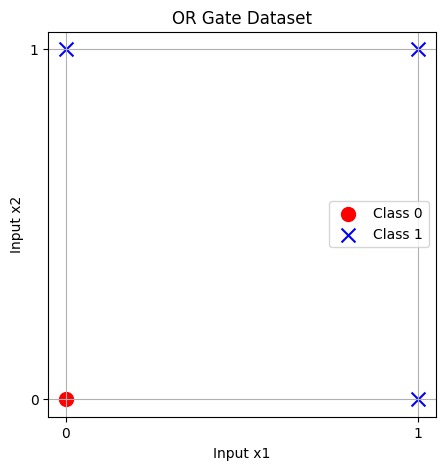

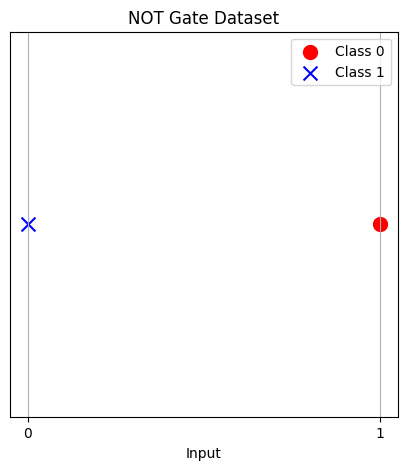

In [ ]:
def plot_dataset(X, y, title):

    plt.figure(figsize=(5,5))

    if X.shape[1] == 2:        # AND / OR

        plt.scatter(
            X[y==0,0], X[y==0,1],
            color='red',
            marker='o',
            s=100,
            label='Class 0'
        )

        plt.scatter(
            X[y==1,0], X[y==1,1],
            color='blue',
            marker='x',
            s=100,
            label='Class 1'
        )

        plt.xlabel("Input x1")
        plt.ylabel("Input x2")
        plt.xticks([0,1])
        plt.yticks([0,1])

    else:                      # NOT

        plt.scatter(
            X[y==0,0],
            np.zeros(np.sum(y==0)),
            color='red',
            marker='o',
            s=100,
            label='Class 0'
        )

        plt.scatter(
            X[y==1,0],
            np.zeros(np.sum(y==1)),
            color='blue',
            marker='x',
            s=100,
            label='Class 1'
        )

        plt.xlabel("Input")
        plt.yticks([])
        plt.xticks([0,1])

    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_dataset(X, y_and, "AND Gate Dataset")
plot_dataset(X, y_or, "OR Gate Dataset")
plot_dataset(X_not, y_not, "NOT Gate Dataset")

Steps 4-10

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)


========== AND Gate ==========

Predicted Outputs
[0. 0.] -> 0
[0. 1.] -> 0
[1. 0.] -> 1
[1. 1.] -> 0

Loss : 0.5483323931694031
Accuracy : 50.0 %


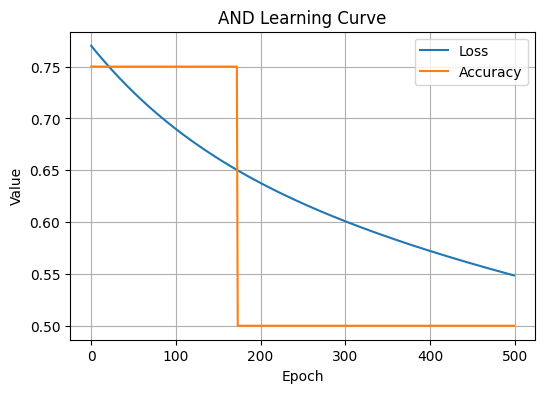

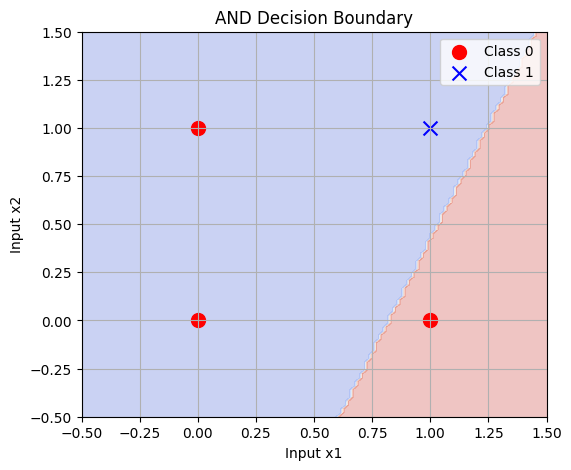


Learned Weights : [ 1.1249504 -0.4758266]
Learned Bias : [-0.92412883]


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)


========== OR Gate ==========

Predicted Outputs
[0. 0.] -> 1
[0. 1.] -> 1
[1. 0.] -> 1
[1. 1.] -> 1

Loss : 0.5033878684043884
Accuracy : 75.0 %


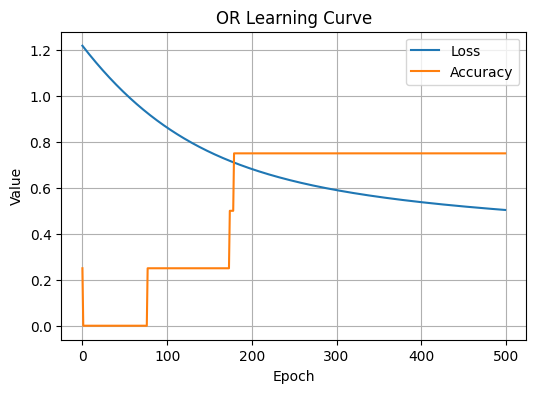

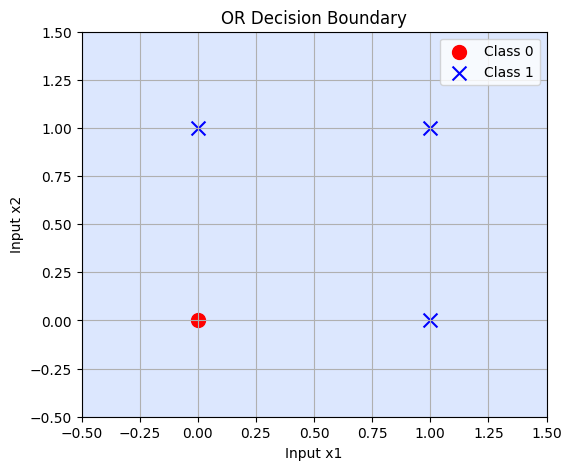


Learned Weights : [0.05131282 0.46445578]
Learned Bias : [0.7869556]


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)


========== NOT Gate ==========

Predicted Outputs
[0.] -> 1
[1.] -> 0

Loss : 0.4191192090511322
Accuracy : 100.0 %


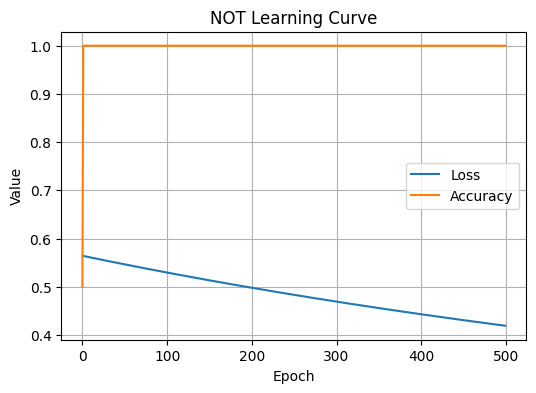


Learned Weights : [-1.3714099]
Learned Bias : [0.3686248]


In [ ]:
def perceptron_boolean(X, y, gate_name):

    # Step 4: Build the Perceptron Model
    model = Sequential([
        Dense(1, input_shape=(X.shape[1],), activation='sigmoid')
    ])
    model.summary()

    # Step 5: Compile the Model
    model.compile(
        optimizer='sgd',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )


    # Step 6: Train the Model
    history = model.fit(
        X,
        y,
        epochs=500,
        verbose=0
    )

    # Step 7: Predict the Output Classes
    predictions = model.predict(X, verbose=0)
    predictions = (predictions > 0.5).astype(int)

    print("\n==========", gate_name, "Gate ==========")

    print("\nPredicted Outputs")
    for i in range(len(X)):
        print(X[i], "->", predictions[i][0])

    # Step 8: Evaluate the Model
    loss, accuracy = model.evaluate(X, y, verbose=0)

    print("\nLoss :", loss)
    print("Accuracy :", accuracy * 100, "%")

    # Step 9(a): Learning Curve
    plt.figure(figsize=(6,4))
    plt.plot(history.history["loss"], label="Loss")
    plt.plot(history.history["accuracy"], label="Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(gate_name + " Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Step 9(b): Decision Boundary (Only for AND & OR)
    if X.shape[1] == 2:

        xx, yy = np.meshgrid(
            np.linspace(-0.5, 1.5, 100),
            np.linspace(-0.5, 1.5, 100)
        )

        grid = np.c_[xx.ravel(), yy.ravel()]

        Z = model.predict(grid, verbose=0)
        Z = (Z > 0.5).astype(int).reshape(xx.shape)

        plt.figure(figsize=(6,5))

        plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

        plt.scatter(
            X[y==0,0], X[y==0,1],
            color="red", marker="o", s=100, label="Class 0"
        )

        plt.scatter(
            X[y==1,0], X[y==1,1],
            color="blue", marker="x", s=100, label="Class 1"
        )

        plt.xlabel("Input x1")
        plt.ylabel("Input x2")
        plt.title(gate_name + " Decision Boundary")
        plt.legend()
        plt.grid(True)
        plt.show()

    # Step 10: Learned Weights and Bias
    weights, bias = model.layers[0].get_weights()

    print("\nLearned Weights :", weights.flatten())
    print("Learned Bias :", bias)

perceptron_boolean(X, y_and, "AND")
perceptron_boolean(X, y_or, "OR")
perceptron_boolean(X_not, y_not, "NOT")